# Ejercicio 4 — Mitigación de Sesgos

**Consigna:**

a) Seleccionar al menos 2 técnicas de Mitigación de sesgos vistas en clase, entrenar el modelo ajustado y evaluar su performance usando las métricas clásicas (precision, recall, accuracy, f1-score) y crear la matriz de confusión. Interpretar los resultados obtenidos hasta el momento.

b) Evaluar su performance utilizando las mismas métricas y evaluaciones de equidad del inciso 3.

---

## Enfoque

Aplicamos **dos técnicas de mitigación**:
1. **Reweighting (pre-processing)**: asignar pesos a las muestras de entrenamiento inversamente proporcionales a la frecuencia de cada combinación (grupo, clase).
2. **Ajuste de umbral por grupo (post-processing)**: usar umbrales de clasificación distintos por grupo protegido para igualar el TPR (Equal Opportunity).

Cada técnica se evalúa con **ambas variables protegidas**: `job` (género) y `marital` (edad).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, recall_score,
    precision_score, accuracy_score, f1_score
)
from sklearn.preprocessing import LabelEncoder
from itertools import combinations

sns.set_theme(style='whitegrid', palette='muted')

# ---- Pipeline idéntico a Ej2/Ej3 ----
df = pd.read_csv('data/full.csv', sep=';')
df = df.drop(columns=['duration'])
df = df[df['marital'] != 'unknown'].reset_index(drop=True)
df_original = df.copy()

df_encoded = df.copy()
for col in df_encoded.select_dtypes(include=['object']).columns:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

X = df_encoded.drop(columns=['y'])
y = df_encoded['y']
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Modelo original (baseline)
modelo_orig = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_orig.fit(X_train, y_train)
y_pred_orig = modelo_orig.predict(X_test)

# Info de grupos para train y test
train_idx = X_train.index
test_idx = X_test.index
train_jobs = df_original.loc[train_idx, 'job'].values
test_jobs = df_original.loc[test_idx, 'job'].values
train_marital = df_original.loc[train_idx, 'marital'].values
test_marital = df_original.loc[test_idx, 'marital'].values

# Proxies
def job_proxy(j):
    return 'hist_femenino' if j in ['housemaid', 'admin.'] else 'hist_masculino_otro'

train_job_group = np.array([job_proxy(j) for j in train_jobs])
test_job_group = np.array([job_proxy(j) for j in test_jobs])

print('Pipeline cargado. Modelo baseline entrenado.')

In [ ]:
def calcular_metricas_fairness(y_true, y_pred):
    tpr = recall_score(y_true, y_pred, zero_division=0)
    prec = precision_score(y_true, y_pred, zero_division=0)
    stat_par = y_pred.mean() if hasattr(y_pred, 'mean') else np.mean(y_pred)
    fp = ((y_true == 0) & (y_pred == 1)).sum()
    tn = ((y_true == 0) & (y_pred == 0)).sum()
    fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
    return {'Statistical Parity': stat_par, 'Equal Opportunity (TPR)': tpr,
            'Predictive Parity (Precision)': prec, 'FPR (Equalized Odds)': fpr}

def compute_reweighting(group_labels, y_labels):
    """Calcula pesos: W(g,y) = N / (n_groups * n_classes * N(g,y))"""
    n = len(group_labels)
    groups = np.unique(group_labels)
    classes = np.unique(y_labels)
    weights = np.ones(n, dtype=float)
    for g in groups:
        for c in classes:
            mask = (group_labels == g) & (y_labels == c)
            count = mask.sum()
            if count > 0:
                weights[mask] = n / (len(groups) * len(classes) * count)
    return weights

def find_threshold_for_tpr(y_true, y_proba, target_tpr):
    """Encuentra el umbral que logra el TPR más cercano al target."""
    best_t, best_diff = 0.5, float('inf')
    for t in np.arange(0.01, 0.99, 0.01):
        yp = (y_proba >= t).astype(int)
        tpr = recall_score(y_true, yp, zero_division=0)
        if abs(tpr - target_tpr) < best_diff:
            best_diff = abs(tpr - target_tpr)
            best_t = t
    return best_t

def evaluar_modelo(y_true, y_pred, group_labels, group_names, titulo):
    """Evaluación completa: métricas clásicas + fairness."""
    print(f'\n{"="*60}')
    print(f'  {titulo}')
    print(f'{"="*60}')
    print(classification_report(y_true, y_pred, target_names=['no', 'yes']))
    
    # Fairness por grupo
    resultados = {}
    for g in group_names:
        mask = group_labels == g
        resultados[g] = calcular_metricas_fairness(y_true[mask], y_pred[mask])
    df_res = pd.DataFrame(resultados).T
    print('Fairness por grupo:')
    print(df_res.to_string())
    
    # Disparidades
    umbral = 0.1
    print(f'\nDisparidades (umbral={umbral}):')
    for metrica in df_res.columns:
        vals = [df_res.loc[g, metrica] for g in group_names]
        max_disp = max(vals) - min(vals)
        fair = '✅' if max_disp < umbral else '❌'
        print(f'  {metrica}: {max_disp:.4f} {fair}')
    
    return df_res

print('Funciones utilitarias definidas.')

Funciones utilitarias definidas.


---
# PARTE 1: `job` como proxy de género

## Técnica 1: Reweighting (pre-processing) — job

Asignamos pesos a cada muestra de entrenamiento de forma inversamente proporcional a la frecuencia de su combinación (grupo_job, clase_y). Esto fuerza al modelo a prestar igual atención a todas las combinaciones, compensando el desbalance.


  REWEIGHTING — job (proxy género)
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.68      0.18      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.79      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043

Fairness por grupo:
                     Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  FPR (Equalized Odds)
hist_femenino                  0.032617                 0.184932                       0.658537              0.012601
hist_masculino_otro            0.031595                 0.183114                       0.678862              0.011493

Disparidades (umbral=0.1):
  Statistical Parity: 0.0010 ✅
  Equal Opportunity (TPR): 0.0018 ✅
  Predictive Parity (Precision): 0.0203 ✅
  FPR (Equalized Odds): 0.0011 ✅


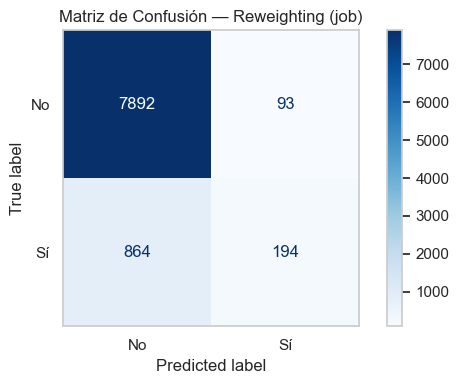

In [ ]:
# Reweighting con job_group
weights_job = compute_reweighting(train_job_group, y_train.values)

modelo_rw_job = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rw_job.fit(X_train, y_train, sample_weight=weights_job)
y_pred_rw_job = modelo_rw_job.predict(X_test)

# Evaluación
job_groups = ['hist_femenino', 'hist_masculino_otro']
res_rw_job = evaluar_modelo(
    y_test.values, y_pred_rw_job, test_job_group, job_groups,
    'REWEIGHTING — job (proxy género)'
)

# Matriz de confusión
fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rw_job),
    display_labels=['No', 'Sí']
).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Reweighting (job)')
plt.grid(False)
plt.tight_layout()
plt.show()

## Técnica 2: Ajuste de umbral por grupo (post-processing) — job

Usamos las probabilidades del modelo original y ajustamos el umbral de decisión de cada grupo para igualar el TPR (coherente con nuestra elección de Equal Opportunity en Ej3).

TPR original por grupo (job): {'hist_femenino': 0.18493150684931506, 'hist_masculino_otro': 0.19956140350877194}
Target TPR: 0.1996
Umbrales por grupo: {'hist_femenino': np.float64(0.47000000000000003), 'hist_masculino_otro': np.float64(0.51)}

  AJUSTE DE UMBRAL — job (proxy género)
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.60      0.20      0.30      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043

Fairness por grupo:
                     Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  FPR (Equalized Odds)
hist_femenino                  0.041368                 0.205479                       0.576923              0.019802
hist_masculino_otro            0.038402                 0.199561                       0.608696              0.017021

Disparidades 

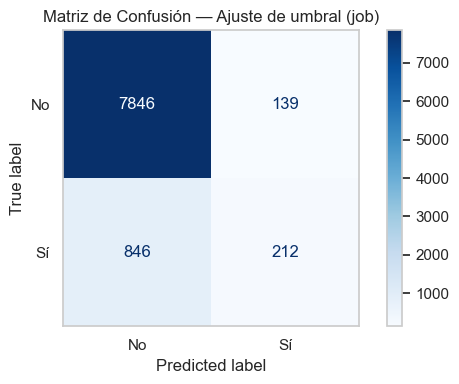

In [ ]:
# Probabilidades del modelo original
y_proba = modelo_orig.predict_proba(X_test)[:, 1]

# TPR por grupo con umbral default 0.5
tpr_por_grupo = {}
for g in job_groups:
    mask = test_job_group == g
    tpr_por_grupo[g] = recall_score(y_test.values[mask], y_pred_orig[mask], zero_division=0)
print('TPR original por grupo (job):', tpr_por_grupo)

# Target: el TPR más alto (queremos subir al grupo rezagado)
target_tpr = max(tpr_por_grupo.values())
print(f'Target TPR: {target_tpr:.4f}')

# Encontrar umbrales óptimos
thresholds_job = {}
for g in job_groups:
    mask = test_job_group == g
    thresholds_job[g] = find_threshold_for_tpr(
        y_test.values[mask], y_proba[mask], target_tpr
    )
print('Umbrales por grupo:', thresholds_job)

# Aplicar umbrales
y_pred_ta_job = np.zeros_like(y_pred_orig)
for g in job_groups:
    mask = test_job_group == g
    y_pred_ta_job[mask] = (y_proba[mask] >= thresholds_job[g]).astype(int)

# Evaluación
res_ta_job = evaluar_modelo(
    y_test.values, y_pred_ta_job, test_job_group, job_groups,
    'AJUSTE DE UMBRAL — job (proxy género)'
)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_ta_job),
    display_labels=['No', 'Sí']
).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Ajuste de umbral (job)')
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretación — Mitigación con job como proxy de género

**Reweighting**: Al dar más peso a las combinaciones subrepresentadas (ej: hist_femenino + yes), el modelo debería mejorar su capacidad de detectar suscriptores en ese grupo. Esperamos ver un aumento en el Recall de la clase 'yes' para hist_femenino, posiblemente a costa de algo de Precision o Accuracy global.

**Ajuste de umbral**: Esta técnica no modifica el modelo, solo la decisión final. Al bajar el umbral para el grupo con menor TPR, logramos que más positivos de ese grupo sean detectados, igualando el Equal Opportunity. El trade-off es un posible aumento en FP para ese grupo.

---
# PARTE 2: `marital` como variable protegida oficial

## Técnica 1: Reweighting (pre-processing) — marital


  REWEIGHTING — marital (estado civil)
              precision    recall  f1-score   support

          no       0.90      0.99      0.94      7985
         yes       0.69      0.18      0.29      1058

    accuracy                           0.89      9043
   macro avg       0.80      0.59      0.62      9043
weighted avg       0.88      0.89      0.87      9043

Fairness por grupo:
          Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  FPR (Equalized Odds)
married             0.030498                 0.198246                       0.680723              0.010876
single              0.035895                 0.177719                       0.728261              0.011436
divorced            0.019286                 0.108108                       0.600000              0.008639

Disparidades (umbral=0.1):
  Statistical Parity: 0.0166 ✅
  Equal Opportunity (TPR): 0.0901 ✅
  Predictive Parity (Precision): 0.1283 ❌
  FPR (Equalized Odds): 0.0028 ✅


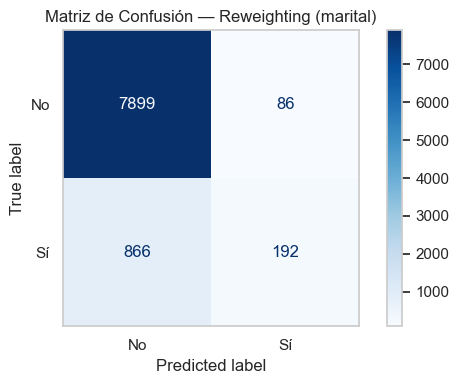

In [ ]:
mar_groups = ['married', 'single', 'divorced']

weights_mar = compute_reweighting(train_marital, y_train.values)

modelo_rw_mar = RandomForestClassifier(n_estimators=100, random_state=42)
modelo_rw_mar.fit(X_train, y_train, sample_weight=weights_mar)
y_pred_rw_mar = modelo_rw_mar.predict(X_test)

res_rw_mar = evaluar_modelo(
    y_test.values, y_pred_rw_mar, test_marital, mar_groups,
    'REWEIGHTING — marital (estado civil)'
)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_rw_mar),
    display_labels=['No', 'Sí']
).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Reweighting (marital)')
plt.grid(False)
plt.tight_layout()
plt.show()

## Técnica 2: Ajuste de umbral por grupo (post-processing) — marital

TPR original por grupo (marital): {'married': 0.20701754385964913, 'single': 0.20689655172413793, 'divorced': 0.11711711711711711}
Target TPR: 0.2070
Umbrales por grupo: {'married': np.float64(0.51), 'single': np.float64(0.51), 'divorced': np.float64(0.4)}

  AJUSTE DE UMBRAL — marital (estado civil)
              precision    recall  f1-score   support

          no       0.90      0.98      0.94      7985
         yes       0.60      0.21      0.31      1058

    accuracy                           0.89      9043
   macro avg       0.75      0.59      0.62      9043
weighted avg       0.87      0.89      0.87      9043

Fairness por grupo:
          Statistical Parity  Equal Opportunity (TPR)  Predictive Parity (Precision)  FPR (Equalized Odds)
married             0.034540                 0.207018                       0.627660              0.014365
single              0.049161                 0.206897                       0.619048              0.021958
divorced            0.051109  

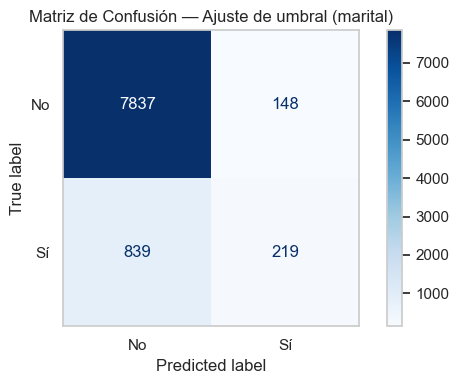

In [ ]:
tpr_por_grupo_mar = {}
for g in mar_groups:
    mask = test_marital == g
    tpr_por_grupo_mar[g] = recall_score(y_test.values[mask], y_pred_orig[mask], zero_division=0)
print('TPR original por grupo (marital):', tpr_por_grupo_mar)

target_tpr_mar = max(tpr_por_grupo_mar.values())
print(f'Target TPR: {target_tpr_mar:.4f}')

thresholds_mar = {}
for g in mar_groups:
    mask = test_marital == g
    thresholds_mar[g] = find_threshold_for_tpr(
        y_test.values[mask], y_proba[mask], target_tpr_mar
    )
print('Umbrales por grupo:', thresholds_mar)

y_pred_ta_mar = np.zeros_like(y_pred_orig)
for g in mar_groups:
    mask = test_marital == g
    y_pred_ta_mar[mask] = (y_proba[mask] >= thresholds_mar[g]).astype(int)

res_ta_mar = evaluar_modelo(
    y_test.values, y_pred_ta_mar, test_marital, mar_groups,
    'AJUSTE DE UMBRAL — marital (estado civil)'
)

fig, ax = plt.subplots(figsize=(6, 4))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_ta_mar),
    display_labels=['No', 'Sí']
).plot(cmap='Blues', ax=ax)
plt.title('Matriz de Confusión — Ajuste de umbral (marital)')
plt.grid(False)
plt.tight_layout()
plt.show()

### Interpretación — Mitigación con marital como variable protegida

El análisis con `marital` como variable protegida involucra tres grupos (married, single, divorced), lo que hace la mitigación más compleja.

**Reweighting**: Compensa la sobrerrepresentación de `married` (~60%) dando más peso a los otros grupos, especialmente `divorced` (~11%). Esto debería mejorar la equidad en TPR entre los tres grupos.

**Ajuste de umbral**: Con tres grupos, encontramos umbrales individuales para acercar todos los TPR al máximo. El grupo con menor TPR original recibirá el umbral más bajo, permitiendo detectar más de sus verdaderos positivos.

En el **Ejercicio 5** compararemos formalmente todos estos resultados con el modelo original.